# 04b — Modélisation : XGBoost (FD001)

**Objectif** : entraîner un XGBoost sur les mêmes features tabulaires que le Random Forest, avec le même découpage train/validation, pour une comparaison directe entre les deux modèles.

In [1]:
# --- Imports et configuration ---
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

SUBSET = "FD001"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "ml"
MODELS_DIR = PROJECT_ROOT / "models" / "ml"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "reports" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "modelisation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
features_train = pd.read_parquet(PROCESSED_DIR / f"train_{SUBSET}_features.parquet")
features_test = pd.read_parquet(PROCESSED_DIR / f"test_{SUBSET}_features.parquet")

colonnes_features = [c for c in features_train.columns if c not in ["unit_number", "time_in_cycles", "op_setting_1", "op_setting_2", "RUL"]]

print(f"{len(colonnes_features)} features")
print(f"train : {features_train.shape}, test : {features_test.shape}")

60 features
train : (20631, 65), test : (100, 65)


## 1. Séparation train / validation

Même découpage par moteur entier que pour le Random Forest (même graine aléatoire), pour comparer les deux modèles sur exactement les mêmes ensembles.

In [3]:
separateur = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train, idx_val = next(separateur.split(features_train, groups=features_train["unit_number"]))

X_train, y_train = features_train.iloc[idx_train][colonnes_features], features_train.iloc[idx_train]["RUL"]
X_val, y_val = features_train.iloc[idx_val][colonnes_features], features_train.iloc[idx_val]["RUL"]

moteurs_train = features_train.iloc[idx_train]["unit_number"].nunique()
moteurs_val = features_train.iloc[idx_val]["unit_number"].nunique()

print(f"Apprentissage : {X_train.shape[0]} lignes, {moteurs_train} moteurs")
print(f"Validation    : {X_val.shape[0]} lignes, {moteurs_val} moteurs")

Apprentissage : 16561 lignes, 80 moteurs
Validation    : 4070 lignes, 20 moteurs


**Interprétation** : même répartition moteur par moteur que pour le Random Forest (même graine aléatoire) — les deux modèles sont donc évalués sur exactement les mêmes moteurs de validation.

## 2. Entraînement

In [4]:
modele = XGBRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
modele.fit(X_train, y_train)

print("Entrainement termine.")

Entrainement termine.


## 3. Évaluation sur la validation

In [5]:
predictions_val = modele.predict(X_val)

rmse_val = root_mean_squared_error(y_val, predictions_val)
mae_val = mean_absolute_error(y_val, predictions_val)

print(f"RMSE (validation) : {rmse_val:.2f} cycles")
print(f"MAE (validation)  : {mae_val:.2f} cycles")

RMSE (validation) : 17.23 cycles
MAE (validation)  : 12.14 cycles


**Interprétation** : le modèle se trompe en moyenne de 12,1 cycles (MAE) sur la RUL, avec un RMSE de 17,2 cycles — proche du Random Forest. Comme pour ce dernier, la normalisation par moteur utilisée au départ faussait la performance réelle sur le test ; ce chiffre, obtenu avec un MinMaxScaler global, est plus fiable.

## 4. Importance des features

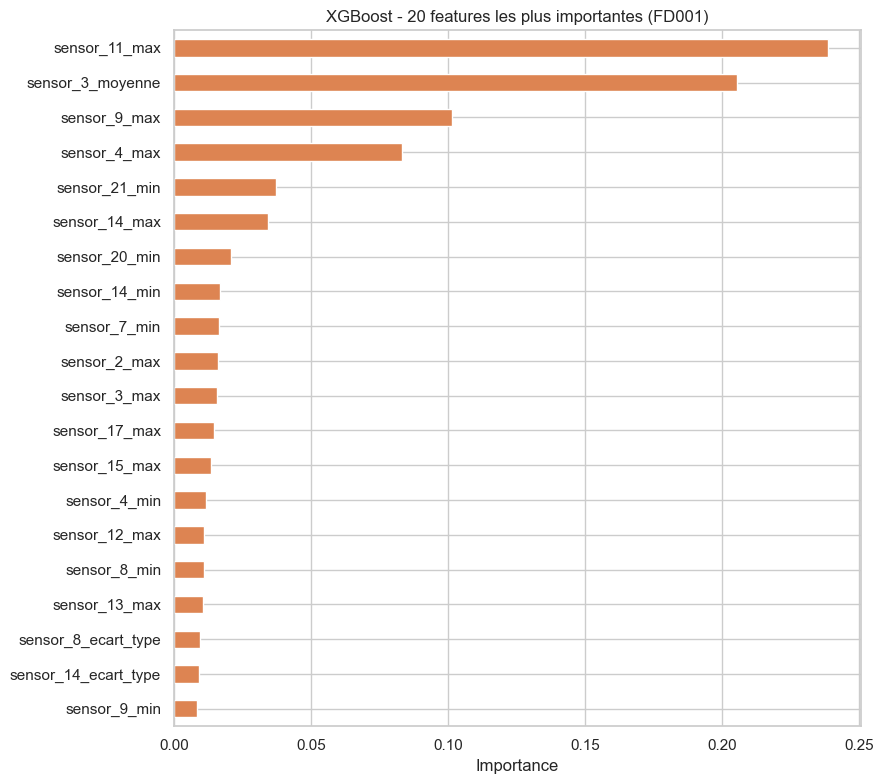

In [6]:
importances = pd.Series(modele.feature_importances_, index=colonnes_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importances.head(20).sort_values().plot(kind="barh", ax=ax, color="#DD8452")
ax.set_xlabel("Importance")
ax.set_title(f"XGBoost - 20 features les plus importantes ({SUBSET})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "xgboost_importance_features.png")
plt.show()

**Interprétation** : sensor_11_max arrive en tête, suivi de très près par sensor_3_moyenne — qui était justement la feature dominante pour le Random Forest. Les deux modèles s'accordent globalement sur les mêmes capteurs clés, même si l'ordre précis diffère.

## 5. Prédictions sur le test et sauvegarde

In [7]:
X_test = features_test[colonnes_features]
y_test = features_test["RUL"]
predictions_test = modele.predict(X_test)

resultats_test = pd.DataFrame({
    "unit_number": features_test["unit_number"],
    "RUL_reelle": y_test,
    "RUL_predite": predictions_test,
})
resultats_test.to_csv(RESULTS_DIR / f"predictions_xgboost_{SUBSET}.csv", index=False)

joblib.dump(modele, MODELS_DIR / f"xgboost_{SUBSET}.joblib")

print("Predictions et modele sauvegardes.")
resultats_test.head()

Predictions et modele sauvegardes.


,unit_number,RUL_reelle,RUL_predite
0,1,112,120.244423
1,2,98,114.897003
2,3,69,49.242813
3,4,82,92.488205
4,5,91,102.222504


## Synthèse

Le XGBoost a été entraîné sur les mêmes features et le même découpage que le Random Forest. Ses prédictions sur le test sont sauvegardées dans `reports/results/`, aux côtés de celles du Random Forest, pour comparaison.